<a href="https://colab.research.google.com/github/hjiwoong/DL/blob/main/day23_practice2_YOLO%ED%95%99%EC%8A%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# RDD2022 일본(Japan) 데이터만으로 YOLO 포트홀/균열 모델을 학습
# 데이터셋 다운로드 1회만 - 받은 파일을 구글 드라이브에 캐시, 이후엔 드라이브에서 가져온다
# W&B 온라인 로깅
# 이어서 학습(resume) - 코랩이 끊겨도 드라이브 체크포인트(last.pt)에서 이어 학습
# best.pt 드라이브 백업
# 증강 병합 - 별도 노트북이 Roboflow seed(큰 포트홀)로 만든 dataset_aug를 train에 합쳐 보강
# 이미지를 눈으로 확인 - 다운도르 직후 원본 몇 장, 학습 후 테스트 이미지 결과

In [1]:
# 셀1. 준비
!pip install -q ultralytics
import os, glob, json, random, shutil, zipfile, urllib.request
import xml.etree.ElementTree as ET
from ultralytics import YOLO, settings

# 구글 드라이브 연결
from google.colab import drive
drive.mount('/content/drive')

# 난수 고정
random.seed(42)

# 구글 드라이브 저장 경로
DRIVE_ROOT = "/content/drive/MyDrive/KWU/DL/roadhazard"
DRIVE_RAW = f"{DRIVE_ROOT}/raw" # 다운로드 캐시
DRIVE_DS = f"{DRIVE_ROOT}/dataset/yolo_japan" #
DRIVE_AUG = f"{DRIVE_ROOT}/dataset_aug" # 증강 노트북 결과
DRIVE_RUNS = f"{DRIVE_ROOT}/runs" # 학습 체크포인트(이어학습용)
DRIVE_WT = f"{DRIVE_ROOT}/weights" # best.pt 백업 폴더
DRIVE_TEST = f"{DRIVE_ROOT}/test_images"
for d in [DRIVE_RAW, DRIVE_RUNS, DRIVE_WT, DRIVE_TEST]:
  os.makedirs(d, exist_ok=True)
COUNTRY = "Japan"
print("Drive 루트:", DRIVE_ROOT, "| 대상 국가:", COUNTRY)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.1/96.1 kB 5.9 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Mounted at /content/drive
Drive 루트: /content/drive/MyDrive/KWU/DL/roadhazard | 대상 국가: Japan


In [3]:
# 셀 2. W&B 온라인 로깅
os.system("pip install -q wandb")
import wandb
from google.colab import userdata
os.environ["WANDB_API_KEY"] = userdata.get("WANDB_API_KEY")
os.environ["WANDB_MODE"] = "online"
os.environ.setdefault("WANDB_PROJECT", "roadhazard")
wandb.login()
settings.update({"wandb": True})
print("W&B 온라인 로깅 ON (project = roadhazard) - 학습 시 wandb.ai에 기록됩니다")

/usr/local/lib/python3.13/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: gimm00999 (gimm00999-kwu) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B 온라인 로깅 ON (project = roadhazard) - 학습 시 wandb.ai에 기록됩니다


In [4]:
# 셀 3. 데이터 준비
FIGSHARE_ARTICLE_ID = 21431547
RAW_LOCAL = "rdd2022_raw"
CLASS_MAP = {"D00": "crack", "D10": "crack", "D20": "crack", "D40": "pothole"}
FINAL_CLASSES = ["pothole", "crack"]
CLASS_TO_ID = {n: i for i, n in enumerate(FINAL_CLASSES)}
VAL_RATIO = 0.2

def _get_figshare_zip_url(article_id): #아티클에서 zip 의 (url, 이름, 크기)를 얻는다.
  req = urllib.request.Request(f"https://api.figshare.com/v2/articles/{article_id}",headers={"User-Agent": "Mozilla/5.0"})
  with urllib.request.urlopen(req) as resp:
    meta = json.loads(resp.read().decode())
  zf = next((f for f in meta.get("files", []) if f["name"].lower().endswith(".zip")), None)
  if zf is None:
    raise RuntimeError("아티클에서 zip 파일을 찾지 못했습니다.")
  return zf["download_url"], zf["name"], zf["size"]

def _download(url, dest): #url 을 받아 dest 파일로 저장
  req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
  with urllib.request.urlopen(req) as resp:
    total = int(resp.headers.get("Content-Length", 0)); done = 0
    with open(dest, "wb") as f:
      while True:
        chunk = resp.read(1024 * 1024)
        if not chunk: break
        f.write(chunk); done += len(chunk)
        if total:
          print(f"\r  {done*100//total}% ({done//(1024*1024)}MB/{total//(1024*1024)}MB)", end="", flush=True) #진행률 출력
  print()

def _find_inner_zip(raw_dir, country): #압축 푼 폴더에서 '{국가}.zip' 찾기
  for root, _, files in os.walk(raw_dir):
    for fn in files:
      if fn.lower() == f"{country.lower()}.zip":
        return os.path.join(root, fn)
  return None #끝까지 없으면 None

def _find_country_dirs(raw): #(이미지폴더, 라벨폴더) 쌍들을 찾는다
  found = []
  for root, _, _ in os.walk(raw):
    if os.path.basename(root) == "images" and "train" in root:
      parent = os.path.dirname(root)
      ann = next((c for c in [os.path.join(parent, "annotations", "xmls"),
                              os.path.join(parent, "annotations"),
                              os.path.join(parent, "Annotations")]
                  if os.path.isdir(c)), None)
      if ann:
        found.append((root, ann))
  return found  #list[(이미지폴더, 라벨폴더)]

def _parse_voc(xp):      #xml 1개 -> 물체 목록
  r = ET.parse(xp).getroot()
  s = r.find("size")
  W, H = int(s.findtext("width")), int(s.findtext("height"))
  out = []
  for o in r.findall("object"):
    b = o.find("bndbox"); name = o.findtext("name")
    if name is None or b is None: continue
    try:
      out.append((name, float(b.findtext("xmin")), float(b.findtext("ymin")),
                  float(b.findtext("xmax")), float(b.findtext("ymax")), W, H))
    except (TypeError, ValueError):
      continue
  return out #[(이름, xmin,ymin,xmax,ymax, W,H)]

def _to_yolo(cid, xmin, ymin, xmax, ymax, W, H): #VOC 절대좌표 -> YOLO 정규화 한 줄 문자열
  clamp = lambda v: max(0.0, min(1.0, v))
  return (f"{cid} {clamp((xmin+xmax)/2/W):.6f} {clamp((ymin+ymax)/2/H):.6f} "
          f"{clamp((xmax-xmin)/W):.6f} {clamp((ymax-ymin)/H):.6f}") #0~1 정규화

def _convert_split_yaml(raw_dir, out_dir): #변환 + train/val 분할 + data.yaml 작성
  pairs = _find_country_dirs(raw_dir)
  assert pairs, "(이미지, 라벨) 폴더 쌍을 못 찾음"
  tmp_i, tmp_l = os.path.join(out_dir, "_ti"), os.path.join(out_dir, "_tl")
  os.makedirs(tmp_i, exist_ok=True); os.makedirs(tmp_l, exist_ok=True)
  stats = {"conv": 0, "no_target": 0, "no_xml": 0}
  for img_dir, ann_dir in pairs:
    for fn in sorted(os.listdir(img_dir)):
      if not fn.lower().endswith((".jpg", ".jpeg", ".png")): continue
      base = os.path.splitext(fn)[0]
      xp = os.path.join(ann_dir, base + ".xml")
      if not os.path.isfile(xp): stats["no_xml"] += 1; continue
      lines = [_to_yolo(CLASS_TO_ID[CLASS_MAP[n]], *rest) for n, *rest in _parse_voc(xp) if n in CLASS_MAP]
      if not lines: stats["no_target"] += 1; continue
      shutil.copy2(os.path.join(img_dir, fn), os.path.join(tmp_i, base + ".jpg"))
      open(os.path.join(tmp_l, base + ".txt"), "w").write("\n".join(lines) + "\n")
      stats["conv"] += 1
  print(f"  변환: {stats['conv']}장 / 관심클래스없음 {stats['no_target']} / XML없음 {stats['no_xml']}")
  assert stats["conv"] > 0, "변환된 이미지 0장"
  bases = sorted(os.path.splitext(f)[0] for f in os.listdir(tmp_i)); random.shuffle(bases)
  n_val = max(1, int(len(bases) * VAL_RATIO)); val = set(bases[:n_val])
  for sp in ("train", "val"):
    os.makedirs(os.path.join(out_dir, "images", sp), exist_ok=True)
    os.makedirs(os.path.join(out_dir, "labels", sp), exist_ok=True)
  for base in bases:
    sp = "val" if base in val else "train"
    shutil.move(os.path.join(tmp_i, base + ".jpg"), os.path.join(out_dir, "images", sp, base + ".jpg"))
    shutil.move(os.path.join(tmp_l, base + ".txt"), os.path.join(out_dir, "labels", sp, base + ".txt"))
  shutil.rmtree(tmp_i, ignore_errors=True); shutil.rmtree(tmp_l, ignore_errors=True)
  with open(os.path.join(out_dir, "data.yaml"), "w", encoding="utf-8") as f:
    f.write(f"path: {os.path.abspath(out_dir)}\ntrain: images/train\nval: images/val\n")
    f.write(f"nc: {len(FINAL_CLASSES)}\nnames: {FINAL_CLASSES}\n")
  print(f"  분할: train {len(bases)-n_val} / val {n_val}  -> data.yaml 작성")

In [5]:
# 셀 4. 데이터 준비 실행 - 구글 드라이브에 이미 있으면 '즉시 생략'
def build_dataset_to_drive(): # 다운로드 → 변환 → 드라이브 저장을 한 번에
  if os.path.exists(f"{DRIVE_DS}/data.yaml"):
    print("변환 데이터셋이 드라이브에 있음 - 다운로드, 변환 생략:", DRIVE_DS)
    return
  os.makedirs(RAW_LOCAL, exist_ok=True)
  japan_zip_drive = f"{DRIVE_RAW}/{COUNTRY}.zip"
  if os.path.exists(japan_zip_drive):
    print("드라이브 캐시 사용:", japan_zip_drive, "(12.6GB 다운로드 생략)")
    inner = japan_zip_drive
  else:
    print("최초 1회 다운로드(12.6GB, 오래 걸립니다)...")
    url, name, size = _get_figshare_zip_url(FIGSHARE_ARTICLE_ID)
    big = os.path.join(RAW_LOCAL, name)
    if not os.path.isfile(big):
      _download(url, big)
    inner_local = _find_inner_zip(RAW_LOCAL, COUNTRY)
    if inner_local is None:
      print("1차 압축 해제 중...")
      with zipfile.ZipFile(big) as z: z.extractall(RAW_LOCAL) # 압축 해제
      inner_local = _find_inner_zip(RAW_LOCAL, COUNTRY)
    assert inner_local is not None, f"{COUNTRY}.zip을 못 찾음"
    shutil.copy2(inner_local, japan_zip_drive) # Japan.zip을 드라이브에 캐시 → 다음부터 다운로드 생략
    print("Japan.zip 드라이브 캐시 완료 - 다음 실행부터 다운로드 생략")
    inner = japan_zip_drive
  target = os.path.join(RAW_LOCAL, COUNTRY, "train", "images")
  if not os.path.isdir(target):
    print("2차 압축 해제 중...")
    with zipfile.ZipFile(inner) as z: z.extractall(RAW_LOCAL) # Japan.zip 압축 해제, 이미지와 라벨 꺼낸다
  local_ds = "yolo_dataset_local"
  if os.path.exists(local_ds): shutil.rmtree(local_ds)
  _convert_split_yaml(RAW_LOCAL, local_ds) # YOLO 변환 + 분할 + yaml을 로컬에 생성
  os.makedirs(os.path.dirname(DRIVE_DS), exist_ok=True)
  if os.path.exists(DRIVE_DS): shutil.rmtree(DRIVE_DS)
  shutil.copytree(local_ds, DRIVE_DS) # 변환본을 드라이브에 캐시
  print("변환 데이터셋 드라이브 저장:", DRIVE_DS)
build_dataset_to_drive() # 함수 실행

변환 데이터셋이 드라이브에 있음 - 다운로드, 변환 생략: /content/drive/MyDrive/KWU/DL/roadhazard/dataset/yolo_japan


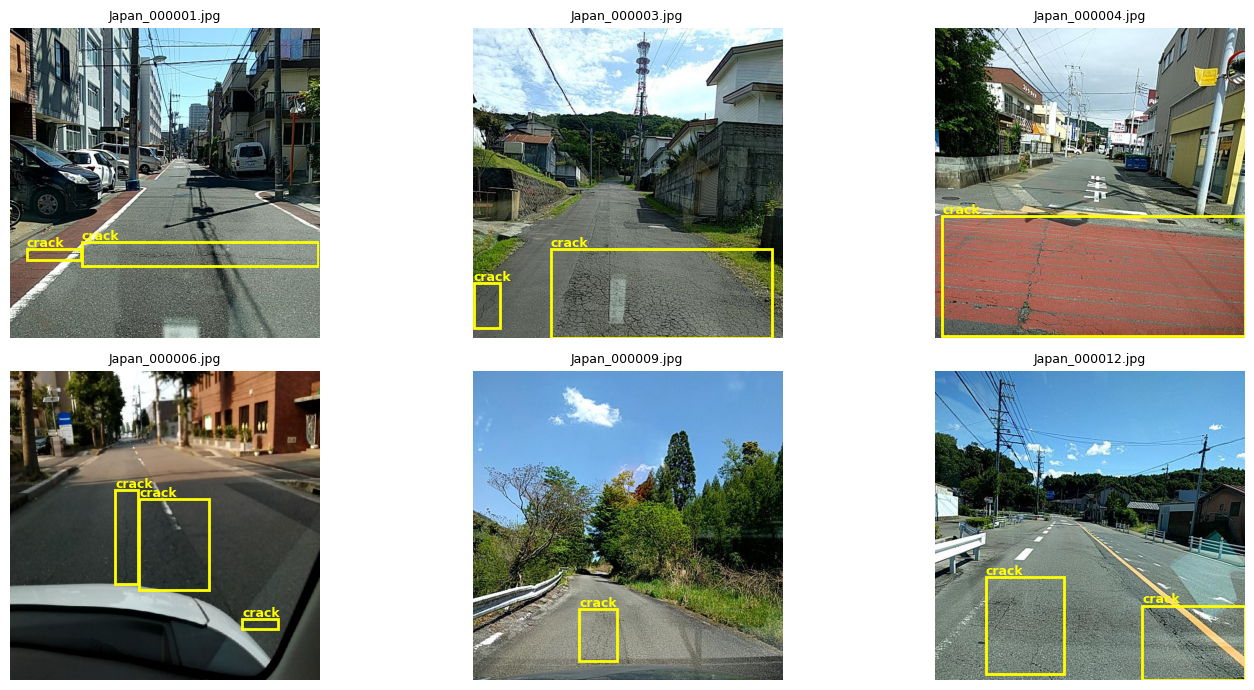

In [11]:
# 셀 5. 다운로드/변환 직후 - 원본 이미지 몇 장 열어 보기
import matplotlib.pyplot as plt
from PIL import Image

def _draw(ax, ip, names):
  img = Image.open(ip)
  W, H = img.size
  ax.imshow(img)
  ax.axis("off")

  lp = ip.replace("/images", "/labels/").rsplit(".", 1)[0] + ".txt"

  if os.path.exists(lp):
    for line in open(lp):
      cls, cx, cy, w, h = map(float, line.split())
      x1, y1 = (cx - w/2) * W, (cy - h/2) * H
      color = "lime" if int(cls) == 0 else "yellow"
      ax.add_patch(plt.Rectangle((x1, y1), w*W, h*H, fill=False, edgecolor=color, lw=2))
      ax.text(x1, y1 - 4, names[int(cls)], color=color, fontsize=9, weight="bold") # 박스 위에 클래스 이름 표기

  ax.set_title(os.path.basename(ip), fontsize=9)

_imgs = sorted(glob.glob(f"{DRIVE_DS}/images/train/*.jpg"))[:6] # 이미지 6장
assert _imgs, f"{DRIVE_DS}/images/train 에 이미지가 없습니다 - 4번 셀을 먼저 실행하세요."
fig, axes = plt.subplots(2,3, figsize=(15,7))
axes = axes.ravel()
for ax, ip in zip(axes, _imgs):
  _draw(ax, ip, FINAL_CLASSES)
for ax in axes[len(_imgs):]:
  ax.axis("off")
plt.tight_layout()
plt.show()

In [12]:
# 셀 6. 학습용 통합 데이터셋 구성 - 원본 + 증강(로컬)
# 증강(dataset_aug)은 train에만 합치고, val은 원본만
LOCAL_TRAIN = "/content/yolo_train"
if os.path.exists(LOCAL_TRAIN): shutil.rmtree(LOCAL_TRAIN) # 매번 새로 구성
shutil.copytree(DRIVE_DS, LOCAL_TRAIN) # 원본(yolo_japan)을 로컬로 폴더 통째 복사
aug_imgs = glob.glob(f"{DRIVE_AUG}/images/train/*") # 증강 이미지 경로들
if aug_imgs:
  for ip in aug_imgs:
    shutil.copy2(ip, f"{LOCAL_TRAIN}/images/train/") # 증강 이미지를 로컬 train에 추가
    lp = ip.replace("/images/", "/labels/").rsplit(".", 1)[0] + ".txt"
    if os.path.exists(lp):
      shutil.copy2(lp, f"{LOCAL_TRAIN}/labels/train/") # 짝 라벨도 함께 복사
  print(f"증강 {len(aug_imgs)}장 병합(train에만)")
else:
  print("증강 데이터(dataset_aug)가 없습니다 - 원본만으로 학습합니다. (증강 노트북 먼저 실행 권장)")
with open(f"{LOCAL_TRAIN}/data.yaml", "w", encoding="utf-8") as f: # 통합본 기준으로 data.yaml 재작성
  f.write(f"path: {LOCAL_TRAIN}\ntrain: images/train\nval: images/val\n")
  f.write(f"nc: {len(FINAL_CLASSES)}\nnames: {FINAL_CLASSES}\n")
DATA_YAML = f"{LOCAL_TRAIN}/data.yaml" # yaml 경로

def _count(split): # train/val의 클래스별 박스 수
  c = {0: 0, 1: 0}
  for lp in glob.glob(f"{LOCAL_TRAIN}/labels/{split}/*.txt"):
    for line in open(lp):
      s = line.split()
      if len(s) == 5: c[int(float(s[0]))] = c.get(int(float(s[0])), 0) + 1 # 줄의 첫 값(클래스)별로 +1
  return c # {0 : 몇 개, 1 : 몇 개} 클래스0 포트홀, 클래스1 균열

print("train 분포:", _count("train"), "| val 분포:", _count("val"), "(0=pothole, 1=crack)")
print("data.yaml:", DATA_YAML)

증강 1148장 병합(train에만)
train 분포: {0: 3346, 1: 11372} | val 분포: {0: 464, 1: 2855} (0=pothole, 1=crack)
data.yaml: /content/yolo_train/data.yaml


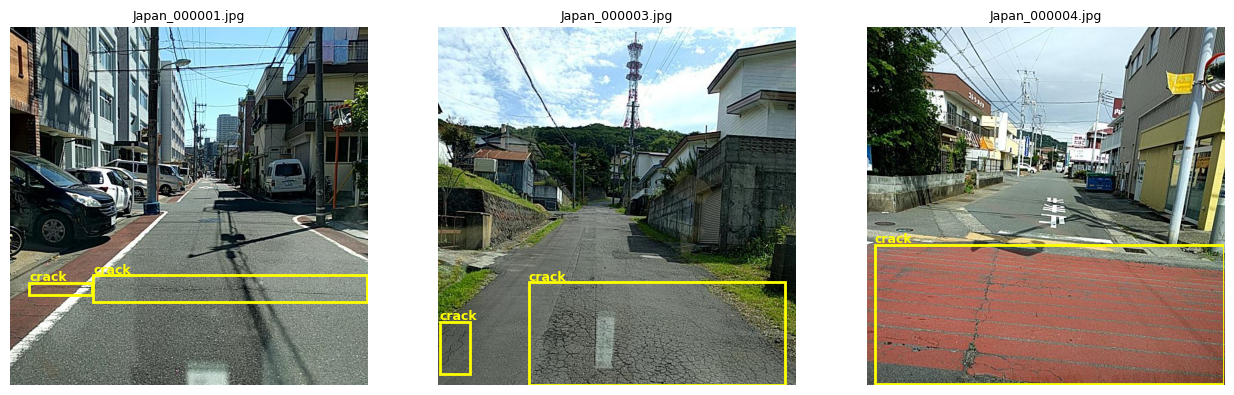

In [13]:
# 셀 7. 라벨 시각화 검증 (통합 데이터셋) - 학습 직전 최종 확인
_imgs = sorted(glob.glob(f"{LOCAL_TRAIN}/images/train/*.jpg"))[:3] # 통합 train 앞 3장
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, ip in zip(axes, _imgs):
  _draw(ax, ip, FINAL_CLASSES)
plt.tight_layout(); plt.show()

In [14]:
# 셀 8. 학습 - W&B 온라인 로깅 + 드라이브 체크포인트 + 이어하기 + best.pt 백업
PROJECT = DRIVE_RUNS # 체크포인트를 '드라이브'에 저장(세션 끊겨도 보존)
NAME = "japan_aug_yolo11s" # 실행 이름
os.environ["WANDB_NAME"] = NAME
last_ckpt = f"{PROJECT}/{NAME}/weights/last.pt" # 마지막 체크포인트 경로
if os.path.exists(last_ckpt):
  print("체크포인트 발견 → 이어서 학습:", last_ckpt)
  model = YOLO(last_ckpt) # 마지막 가중치 로드
  results = model.train(resume = True) # 저장된 설정 그대로 이어서 학습, W&B도 이어 로깅
else:
  print("처음부터 학습(체크포인트는 드라이브에 저장됨)")
  model = YOLO("yolo11s.pt") # COCO 사전학습 가중치에서 전이학습 시작(자동 다운로드)
  results = model.train(
      data = DATA_YAML,
      epochs = 100, imgsz = 640, batch = 16,
      patience = 20, # 20에폭동안 개선 없으면 조기 종료
      project = PROJECT, name = NAME, exist_ok = True, # 저장 위치
      save_period = 5 # 5에폭마다 스냅샷 저장(last.pt는 매 에폭 갱신)
  )
best = f"{PROJECT}/{NAME}/weights/best.pt" # 가장 성능 좋았던 가중치 경로
os.makedirs(DRIVE_WT, exist_ok=True)
shutil.copy2(best, f"{DRIVE_WT}/best.pt") # best.pt를 별도 폴더에 백업
print("best.pt:", best)
print("백업:", f"{DRIVE_WT}/best.pt")

처음부터 학습(체크포인트는 드라이브에 저장됨)
Ultralytics 8.4.174 🚀 Python-3.13.16 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_train/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=japan_aug_yolo11s, nbs=64, nms=No

Overriding model.yaml nc=80 with nc=2

                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [64, 128, 1, False, 0.25]     
  3                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
  4                  -1  1    103360  ultralytics.nn.modules.block.C3k2            [128, 256, 1, False, 0.25]    
  5                  -1  1    590336  ultralytics.nn.modules.conv.Conv             [256, 256, 3, 2]              
  6                  -1  1    346112  ultralytics.nn.modules.block.C3k2            [256, 256, 1, True]           
  7                  -1  1   1180672  ultralytics

KeyboardInterrupt: 

In [10]:
# 셀 9. 최종 테스트 - 새 이미지로 결과를 화면에 표시
# test_images/ 에 학습 (증강 seed)과 겹치지 않는 '새' 이미지를 올려둔다
os.system("apt-get -qq instal -y fonts-nanum > /dev/null 2>&1") # 한글 폰트
import matplotlib.pyplot as plt, matplotlib.font_manager as fm
_fp = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
if os.path.exists(_fp):
  fm.fontManager.addfont(_fp); plt.rcParams["font.family"] = "NanumGothic" # 한글 폰트 등록
plt.rcParams["axes.unicode_minus"] = False # 마이너스 기호 깨짐 방지

model = YOLO(f"{DRIVE_WT}/best.pt") # 백업한 최종 모델 로드
tests = sorted(glob.glob(f"{DRIVE_TEST}/*.jpg")
              + glob.glob(f"{DRIVE_TEST}/*.jpeg")
              + glob.glob(f"{DRIVE_TEST}/*.jpeg"))
assert tests, f"{DRIVE_TEST}에 테스트 이미지를 올리세요 (seed와 겹치지 않는 '새' 큰 포트홀 이미지)"
tests = tests[:6]
n = len(tests)

fig, axes = plt.subplots(1, n, figsize=(6*n, 5))
if n == 1: axes = [axes]
for ax, ip in zip(axes, tests):
  r = model(ip, conf=0.1, iou=0.5, verbose=False)[0] # model(이미지)로 추론, conf=신뢰도 문턱, iou=중복박스 제거 기준, [0]=첫 이미지 결과
  names = [r.names[int(b.cls)] for b in r.boxes] # r.boxes=감지 박스들, r.names={0:'pothole', 1:'crack'} 감지된 박스의 클래스 이름들
  ax.imshow(r.plot()[:,:,::-1]); ax.axis("off")
  ax.set_title(f"{os.path.basename(ip)} (감지 {len(r.boxes)}개)\n{names}", fontsize=9)
plt.tight_layout()
plt.savefig(f"{DRIVE_ROOT}/test_result.png", dpi=110)
plt.show()
print("결과 저장:", f"{DRIVE_ROOT}/test_result.png")